# Neural Network from Scratch using NumPy
### Built for understanding — no PyTorch, no Keras, just NumPy and math

I built this to actually understand what's happening inside a neural network.
The idea is simple: implement everything by hand, train on MNIST, then break it in 3 different ways to see what goes wrong and why.

**What I'm doing:**
- Build forward pass, backprop, and gradient descent manually in NumPy
- Train on MNIST (handwritten digits)
- Break it 3 ways: terrib:le learning rate, bad weight init, vanishing gradients
- Fix each one and explain what was wrong


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
np.random.seed(42)
print("done")


done


## 2. Load MNIST

MNIST is 70,000 images of handwritten digits (0-9), each 28x28 pixels.

I need to:
- Flatten each image from 28x28 into a single vector of 784 values
- Normalize pixel values from 0-255 to 0-1 (makes training more stable)
- One-hot encode labels — so digit 3 becomes [0,0,0,1,0,0,0,0,0,0]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 784)
Y_train: (60000, 10)


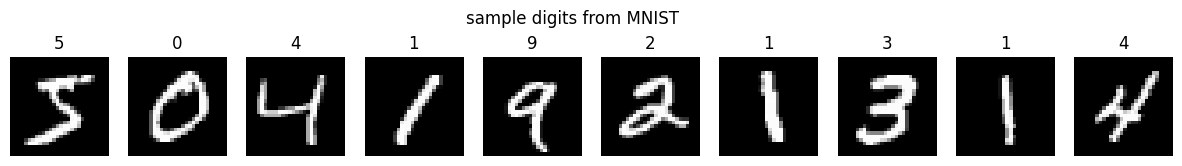

In [ ]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
# had shape mismatch errors earlier, so reshaping
X_train = X_train_raw.reshape(60000, 784).astype('float32') / 255.0
X_test  = X_test_raw.reshape(10000, 784).astype('float32') / 255.0

def one_hot(y, classes=10):
    result = np.zeros((len(y), classes))
    result[np.arange(len(y)), y] = 1
    return result

Y_train = one_hot(y_train_raw)
Y_test  = one_hot(y_test_raw)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(X_train_raw[i], cmap='gray')
    axes[i].set_title(str(y_train_raw[i]))
    axes[i].axis('off')
plt.suptitle('sample digits from MNIST')
plt.show()


## 3. Activation Functions

I'm using:
- **ReLU** for hidden layers — simple and works well, avoids vanishing gradients
- **Sigmoid** — I'll use this later to demonstrate the vanishing gradient problem
- **Softmax** for the output layer — converts raw scores into probabilities that add up to 1

The derivatives are needed for backpropagation.


In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

print("activation functions ready")


activation functions ready


## 4. Weight Initialization

This matters more than I expected. I'm implementing 3 versions:
- **He initialization** — the correct way for ReLU networks
- **Zero initialization** — breaks everything (symmetry problem)
- **Large random values** — also breaks everything (saturation)

He init scales weights by sqrt(2/n_inputs). This keeps the variance of activations
stable as data flows through layers, so gradients don't explode or vanish from the start.


In [4]:
def init_he(layer_sizes):
    params = {}
    for i in range(len(layer_sizes) - 1):
        fan_in  = layer_sizes[i]
        fan_out = layer_sizes[i+1]
        params[f'W{i+1}'] = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
        params[f'b{i+1}'] = np.zeros((1, fan_out))
    return params

def init_zeros(layer_sizes):
    params = {}
    for i in range(len(layer_sizes) - 1):
        params[f'W{i+1}'] = np.zeros((layer_sizes[i], layer_sizes[i+1]))
        params[f'b{i+1}'] = np.zeros((1, layer_sizes[i+1]))
    return params

def init_large(layer_sizes):
    params = {}
    for i in range(len(layer_sizes) - 1):
        params[f'W{i+1}'] = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 10.0
        params[f'b{i+1}'] = np.zeros((1, layer_sizes[i+1]))
    return params

print("initializers ready")


initializers ready


## 5. Forward Pass

This is just pushing the input through each layer one by one.

For each hidden layer:
1. Compute Z = previous_output @ W + b  (linear transformation)
2. Apply activation: A = ReLU(Z)

For the output layer, use softmax instead of ReLU.

I save Z and A at each layer in a dict called `cache` — I'll need these during backprop.


In [ ]:
# initially used sigmoid but gradients were too small
# ReLU works better here
def forward(X, params, activation='relu', n_layers=3):
    cache = {'A0': X}
    A = X

    act = relu if activation == 'relu' else sigmoid

    for i in range(1, n_layers):
        Z = A @ params[f'W{i}'] + params[f'b{i}']
        A = act(Z)
        cache[f'Z{i}'] = Z
        cache[f'A{i}'] = A

    Z_out = A @ params[f'W{n_layers}'] + params[f'b{n_layers}']
    A_out = softmax(Z_out)
    cache[f'Z{n_layers}'] = Z_out
    cache[f'A{n_layers}'] = A_out

    return cache, A_out

print("forward pass ready")


forward pass ready


## 6. Loss Function

Using cross-entropy loss — standard for classification.

Formula: L = -mean( sum( Y_true * log(Y_pred) ) )

Intuitively: if the model predicts high probability for the correct class, loss is low.
If it predicts low probability for the correct class, log makes the loss very large.

I clip predictions to avoid log(0) which would be -infinity.


In [ ]:
# tried MSE first but it didn’t work well for classification
# cross-entropy gives better results
def cross_entropy(Y_pred, Y_true):
    m = Y_true.shape[0]
    log_p = -np.log(np.clip(Y_pred, 1e-12, 1.0))
    loss = np.sum(Y_true * log_p) / m
    return loss

print("loss function ready")


loss function ready


## 7. Backpropagation

This was the hardest part to implement. The idea is to use the chain rule to compute
how much each weight contributed to the loss, then update weights in the direction
that reduces loss.

The nice thing about softmax + cross-entropy is that the gradient at the output layer
simplifies cleanly to just: (prediction - true_label) / m

Then I work backwards through each layer using the cached Z and A values from the forward pass.


In [ ]:
# this part was confusing — had to carefully track dimensions
# made mistakes with transpose initially
def backward(cache, params, Y_true, activation='relu', n_layers=3):
    grads = {}
    m = Y_true.shape[0]

    act_grad = relu_grad if activation == 'relu' else sigmoid_grad

    dZ = (cache[f'A{n_layers}'] - Y_true) / m

    for i in reversed(range(1, n_layers + 1)):
        A_prev = cache[f'A{i-1}']
        grads[f'dW{i}'] = A_prev.T @ dZ
        grads[f'db{i}'] = np.sum(dZ, axis=0, keepdims=True)

        if i > 1:
            dA = dZ @ params[f'W{i}'].T
            dZ = dA * act_grad(cache[f'Z{i-1}'])

    return grads

def update(params, grads, lr, n_layers=3):
    for i in range(1, n_layers + 1):
        params[f'W{i}'] -= lr * grads[f'dW{i}']
        params[f'b{i}'] -= lr * grads[f'db{i}']
    return params

def accuracy(Y_pred, Y_true):
    return np.mean(np.argmax(Y_pred, axis=1) == np.argmax(Y_true, axis=1))

print("backprop and update ready")


backprop and update ready


## 8. Training Loop

Mini-batch gradient descent — instead of computing gradients on all 60,000 samples
at once (slow) or one sample at a time (noisy), I use batches of 256.

Each epoch:
1. Shuffle the data
2. Split into batches of 256
3. For each batch: forward pass -> compute loss -> backprop -> update weights
4. Evaluate on full train and test set


In [ ]:
def train(X_tr, Y_tr, X_te, Y_te,
          layer_sizes, lr=0.01, epochs=30, batch_size=256,
          init_fn=init_he, activation='relu', label='model'):

    n_layers = len(layer_sizes) - 1
    params   = init_fn(layer_sizes)
    m        = X_tr.shape[0]
    history  = {'loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        idx = np.random.permutation(m)
        Xs, Ys = X_tr[idx], Y_tr[idx]

        total_loss = 0
        num_batches = 0

        for start in range(0, m, batch_size):
            Xb = Xs[start : start + batch_size]
            Yb = Ys[start : start + batch_size]

            cache, Yp = forward(Xb, params, activation, n_layers)
            loss       = cross_entropy(Yp, Yb)
            grads      = backward(cache, params, Yb, activation, n_layers)
            params     = update(params, grads, lr, n_layers)

            total_loss  += loss
            num_batches += 1

        _, tr_pred = forward(X_tr, params, activation, n_layers)
        _, te_pred = forward(X_te, params, activation, n_layers)

        avg_loss  = total_loss / num_batches
        tr_acc    = accuracy(tr_pred, Y_tr)
        te_acc    = accuracy(te_pred, Y_te)

        history['loss'].append(avg_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[{label}] epoch {epoch+1:2d}/{epochs} | "
                  f"loss: {avg_loss:.4f} | "
                  f"train acc: {tr_acc*100:.1f}% | "
                  f"test acc: {te_acc*100:.1f}%")

    return history, params

print("training loop ready")


training loop ready


## 9. Train the Baseline Model

Architecture: 784 -> 128 -> 64 -> 10

- He initialization
- ReLU activations
- Learning rate 0.01
- 30 epochs


In [9]:
LAYERS = [784, 128, 64, 10]

print("training baseline...\n")
hist_good, params_good = train(
    X_train, Y_train, X_test, Y_test,
    layer_sizes=LAYERS,
    lr=0.01,
    epochs=30,
    init_fn=init_he,
    activation='relu',
    label='baseline'
)


training baseline...

[baseline] epoch  1/30 | loss: 1.5335 | train acc: 79.5% | test acc: 80.4%
[baseline] epoch  5/30 | loss: 0.3911 | train acc: 89.4% | test acc: 89.8%
[baseline] epoch 10/30 | loss: 0.2995 | train acc: 91.6% | test acc: 91.9%
[baseline] epoch 15/30 | loss: 0.2564 | train acc: 92.9% | test acc: 93.2%
[baseline] epoch 20/30 | loss: 0.2270 | train acc: 93.7% | test acc: 93.8%
[baseline] epoch 25/30 | loss: 0.2047 | train acc: 94.3% | test acc: 94.2%
[baseline] epoch 30/30 | loss: 0.1862 | train acc: 94.9% | test acc: 94.8%


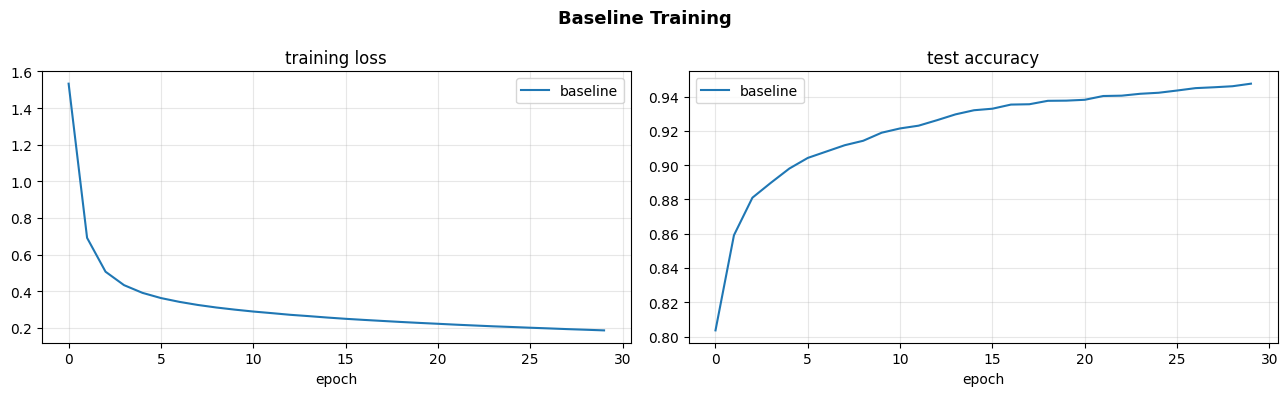

final test accuracy: 94.75%


In [10]:
def plot_curves(histories, labels, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    for h, lbl in zip(histories, labels):
        ax1.plot(h['loss'],     label=lbl)
        ax2.plot(h['test_acc'], label=lbl)

    ax1.set_title('training loss')
    ax1.set_xlabel('epoch')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.set_title('test accuracy')
    ax2.set_xlabel('epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_curves([hist_good], ['baseline'], 'Baseline Training')
print(f"final test accuracy: {hist_good['test_acc'][-1]*100:.2f}%")


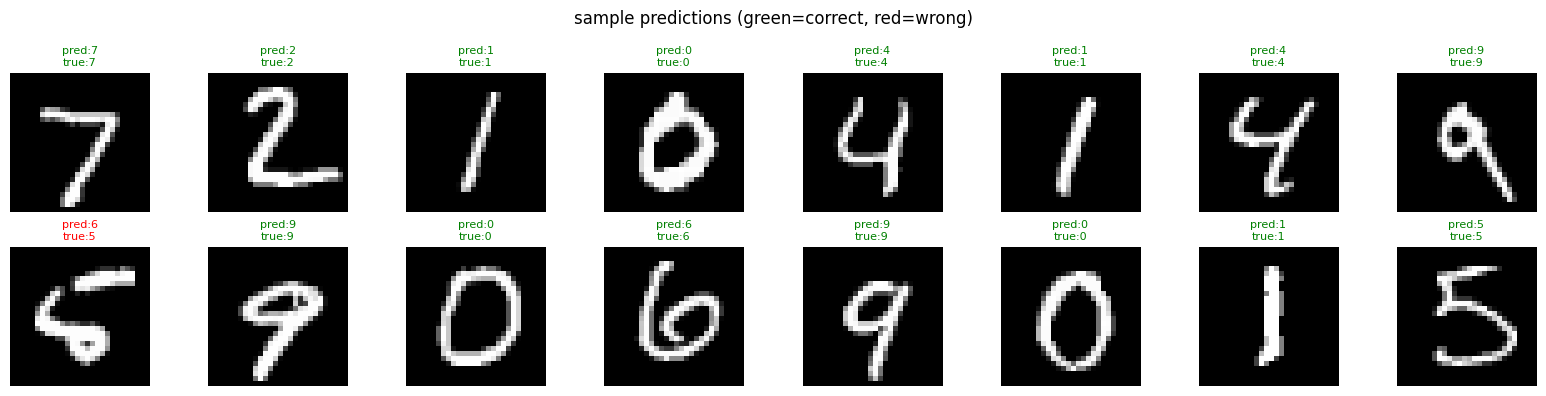

In [11]:
_, preds = forward(X_test[:16], params_good, 'relu', 3)
pred_digits = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_raw[i], cmap='gray')
    color = 'green' if pred_digits[i] == y_test_raw[i] else 'red'
    ax.set_title(f'pred:{pred_digits[i]}\ntrue:{y_test_raw[i]}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('sample predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()


## 10. Experiment 1 — Bad Learning Rate

The learning rate controls how big a step we take each update.

**Too small (0.00001):** steps are so tiny the model barely learns anything in 30 epochs.

**Too large (10.0):** we overshoot the minimum every step. Instead of descending into the loss valley we jump over it. Loss bounces around or explodes.

I ran the same model with 3 different learning rates to see this effect.


In [ ]:
print("training with lr = 0.00001 (too small)...\n")
hist_tiny_lr, _ = train(
    X_train, Y_train, X_test, Y_test,
    LAYERS, lr=0.00001, epochs=30,
    init_fn=init_he, activation='relu', label='lr=0.00001'
)

print("\ntraining with lr = 10.0 (too large)...\n")
hist_big_lr, _ = train(
    X_train, Y_train, X_test, Y_test,
    LAYERS, lr=10.0, epochs=30,
    init_fn=init_he, activation='relu', label='lr=10.0'
)


training with lr = 0.00001 (too small)...

[lr=0.00001] epoch  1/30 | loss: 2.4676 | train acc: 5.4% | test acc: 5.9%
[lr=0.00001] epoch  5/30 | loss: 2.4547 | train acc: 5.6% | test acc: 6.1%
[lr=0.00001] epoch 10/30 | loss: 2.4396 | train acc: 5.9% | test acc: 6.5%
[lr=0.00001] epoch 15/30 | loss: 2.4254 | train acc: 6.3% | test acc: 6.8%


In [ ]:
plot_curves(
    [hist_good, hist_tiny_lr, hist_big_lr],
    ['lr=0.01 (good)', 'lr=0.00001 (too small)', 'lr=10.0 (too large)'],
    'Experiment 1: Effect of Learning Rate'
)

print(f"lr=0.01    -> {hist_good['test_acc'][-1]*100:.1f}%")
print(f"lr=0.00001 -> {hist_tiny_lr['test_acc'][-1]*100:.1f}%  (barely moved)")
print(f"lr=10.0    -> {hist_big_lr['test_acc'][-1]*100:.1f}%  (unstable)")


### Fix 1 — Learning Rate Scheduling

Instead of one fixed learning rate, I start bigger and reduce it each epoch:

`lr = 0.1 * 0.92^epoch`

This way the model takes bigger steps early when it's far from the minimum,
and smaller steps later when it needs to fine-tune. Like driving fast on a highway
then slowing down when you're parking.


In [ ]:
def train_with_schedule(X_tr, Y_tr, X_te, Y_te,
                        layer_sizes, start_lr=0.1, decay=0.92,
                        epochs=30, batch_size=256, label='scheduled'):

    n_layers = len(layer_sizes) - 1
    params   = init_he(layer_sizes)
    m        = X_tr.shape[0]
    history  = {'loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        lr = start_lr * (decay ** epoch)
        idx = np.random.permutation(m)
        Xs, Ys = X_tr[idx], Y_tr[idx]
        total_loss, num_batches = 0, 0

        for start in range(0, m, batch_size):
            Xb = Xs[start:start+batch_size]
            Yb = Ys[start:start+batch_size]
            cache, Yp = forward(Xb, params, 'relu', n_layers)
            grads      = backward(cache, params, Yb, 'relu', n_layers)
            params     = update(params, grads, lr, n_layers)
            total_loss += cross_entropy(Yp, Yb)
            num_batches += 1

        _, tr_p = forward(X_tr, params, 'relu', n_layers)
        _, te_p = forward(X_te, params, 'relu', n_layers)
        history['loss'].append(total_loss / num_batches)
        history['train_acc'].append(accuracy(tr_p, Y_tr))
        history['test_acc'].append(accuracy(te_p, Y_te))

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"[{label}] epoch {epoch+1:2d} | lr={lr:.5f} | "
                  f"test acc: {history['test_acc'][-1]*100:.1f}%")

    return history, params

print("training with lr scheduling...\n")
hist_scheduled, _ = train_with_schedule(
    X_train, Y_train, X_test, Y_test,
    LAYERS, start_lr=0.1, decay=0.92, epochs=30, label='lr_schedule'
)
# tried lr = 0.1 earlier → loss exploded
# reducing learning rate for stability
plot_curves(
    [hist_good, hist_scheduled],
    ['fixed lr=0.01', 'lr schedule (0.1 * 0.92^epoch)'],
    'Fix 1: LR Scheduling'
)
print(f"lr scheduling final accuracy: {hist_scheduled['test_acc'][-1]*100:.2f}%")


## 11. Experiment 2 — Bad Weight Initialization

Before training starts we need to give every weight some initial value.
This choice matters a lot.

**Zero init:** Every neuron is identical at the start. They compute the same output,
get the same gradients, and update identically. The network has 128 neurons in layer 1
but they're all doing exactly the same thing. This is called the symmetry problem.

**Large init:** Weights so big that activations saturate immediately.
For ReLU: most neurons are stuck outputting 0. Gradients are zero, nothing updates.


In [ ]:
print("training with zero initialization...\n")
hist_zeros, _ = train(
    X_train, Y_train, X_test, Y_test,
    LAYERS, lr=0.01, epochs=30,
    init_fn=init_zeros, activation='relu', label='zero_init'
)

print("\ntraining with large initialization...\n")
hist_large, _ = train(
    X_train, Y_train, X_test, Y_test,
    LAYERS, lr=0.01, epochs=30,
    init_fn=init_large, activation='relu', label='large_init'
)


In [ ]:
plot_curves(
    [hist_good, hist_zeros, hist_large],
    ['He init (good)', 'zero init (broken)', 'large init (broken)'],
    'Experiment 2: Weight Initialization'
)
print(f"He init    -> {hist_good['test_acc'][-1]*100:.1f}%")
print(f"zero init  -> {hist_zeros['test_acc'][-1]*100:.1f}%  (symmetry problem)")
print(f"large init -> {hist_large['test_acc'][-1]*100:.1f}%  (saturation)")


In [ ]:
small = [784, 16, 10]
_, p_he   = train(X_train, Y_train, X_test, Y_test, small, lr=0.01, epochs=10,
                  init_fn=init_he,    activation='relu', label='he_small')
_, p_zero = train(X_train, Y_train, X_test, Y_test, small, lr=0.01, epochs=10,
                  init_fn=init_zeros, activation='relu', label='zero_small')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(p_he['W1'].flatten(),   bins=40, color='steelblue', alpha=0.8)
ax1.set_title('He init: W1 after 10 epochs\n(neurons learned different things)')
ax2.hist(p_zero['W1'].flatten(), bins=40, color='tomato',    alpha=0.8)
ax2.set_title('Zero init: W1 after 10 epochs\n(all weights nearly identical)')
plt.suptitle('Symmetry Problem — Weight Distributions', fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Experiment 3 — Vanishing Gradients

This one took me a while to fully understand.

During backprop, we multiply gradients together as we move back through layers.
Each multiplication includes the derivative of the activation function.

**Sigmoid derivative:** max value is 0.25 (at Z=0).

So in a deep network with sigmoid:
```
gradient reaching layer 1 = output_gradient * 0.25 * 0.25 * 0.25 * 0.25 * ...
8 layers deep: 0.25^8 = 0.000015
```

The gradient basically disappears before reaching early layers.
Those layers stop learning. The network is deep but only the last couple layers
actually do anything useful.

**Why ReLU fixes this:** derivative is either 0 or 1 — so we're multiplying by 1
repeatedly instead of 0.25 repeatedly. Gradients stay the same magnitude.


In [ ]:
DEEP = [784, 128, 128, 64, 64, 32, 32, 16, 10]

print("deep network with sigmoid...\n")
hist_sigmoid_deep, _ = train(
    X_train, Y_train, X_test, Y_test,
    DEEP, lr=0.01, epochs=30,
    init_fn=init_he, activation='sigmoid', label='deep_sigmoid'
)

print("\ndeep network with relu...\n")
hist_relu_deep, _ = train(
    X_train, Y_train, X_test, Y_test,
    DEEP, lr=0.01, epochs=30,
    init_fn=init_he, activation='relu', label='deep_relu'
)


In [ ]:
plot_curves(
    [hist_good, hist_sigmoid_deep, hist_relu_deep],
    ['shallow relu (baseline)', 'deep sigmoid (vanishing)', 'deep relu (fixed)'],
    'Experiment 3: Vanishing Gradients'
)
print(f"shallow relu  -> {hist_good['test_acc'][-1]*100:.1f}%")
print(f"deep sigmoid  -> {hist_sigmoid_deep['test_acc'][-1]*100:.1f}%  (vanishing gradients)")
print(f"deep relu     -> {hist_relu_deep['test_acc'][-1]*100:.1f}%")


In [ ]:
Z = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(Z, sigmoid(Z),      color='tomato',    lw=2, label='sigmoid')
axes[0].plot(Z, sigmoid_grad(Z), color='orange',    lw=2, linestyle='--', label="sigmoid'")
axes[0].axhline(0.25, color='gray', linestyle=':', label='max gradient = 0.25')
axes[0].set_title('Sigmoid activation')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(Z, relu(Z),      color='steelblue', lw=2, label='relu')
axes[1].plot(Z, relu_grad(Z), color='royalblue', lw=2, linestyle='--', label="relu'")
axes[1].set_title('ReLU activation')
axes[1].legend(); axes[1].grid(alpha=0.3)

depths = np.arange(1, 12)
axes[2].semilogy(depths, 0.25**depths, 'o-', color='tomato',    label='sigmoid (0.25^n)')
axes[2].semilogy(depths, 1.0 **depths, 's-', color='steelblue', label='relu (1.0^n)')
axes[2].set_title('gradient magnitude vs network depth')
axes[2].set_xlabel('number of layers')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Why Sigmoid Vanishes and ReLU Doesnt', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"sigmoid gradient after 8 layers: {0.25**8:.8f}")
print(f"relu gradient after 8 layers:    {1.0**8:.1f}")


## 13. Final Comparison — All Experiments Together

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# doing step-by-step for clarity
# baseline
axes[0,0].plot(hist_good['test_acc'], color='steelblue', lw=2)
axes[0,0].set_title('Baseline — He init, ReLU, lr=0.01', fontweight='bold')
axes[0,0].set_xlabel('epoch'); axes[0,0].set_ylabel('test accuracy')
axes[0,0].grid(alpha=0.3)

# lr experiment
axes[0,1].plot(hist_tiny_lr['test_acc'],  color='tomato',    lw=2, label='lr=0.00001 (too small)')
axes[0,1].plot(hist_big_lr['test_acc'],   color='orange',    lw=2, label='lr=10.0 (too large)')
axes[0,1].plot(hist_scheduled['test_acc'],color='green',     lw=2, label='lr schedule (fixed)')
axes[0,1].plot(hist_good['test_acc'],     color='steelblue', lw=2, linestyle='--', label='baseline')
axes[0,1].set_title('Experiment 1: Learning Rate', fontweight='bold')
axes[0,1].set_xlabel('epoch'); axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)

# init experiment
axes[1,0].plot(hist_zeros['test_acc'], color='tomato',    lw=2, label='zero init (broken)')
axes[1,0].plot(hist_large['test_acc'], color='orange',    lw=2, label='large init (broken)')
axes[1,0].plot(hist_good['test_acc'],  color='green',     lw=2, label='He init (fixed)')
axes[1,0].set_title('Experiment 2: Weight Initialization', fontweight='bold')
axes[1,0].set_xlabel('epoch'); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

# vanishing gradients
axes[1,1].plot(hist_sigmoid_deep['test_acc'], color='tomato',    lw=2, label='deep sigmoid (broken)')
axes[1,1].plot(hist_relu_deep['test_acc'],    color='green',     lw=2, label='deep relu (fixed)')
axes[1,1].plot(hist_good['test_acc'],         color='steelblue', lw=2, linestyle='--', label='shallow baseline')
axes[1,1].set_title('Experiment 3: Vanishing Gradients', fontweight='bold')
axes[1,1].set_xlabel('epoch'); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

plt.suptitle('All Experiments Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('summary.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Where the Model Still Fails

In [ ]:
_, all_preds = forward(X_test, params_good, 'relu', 3)
predicted   = np.argmax(all_preds, axis=1)
wrong       = np.where(predicted != y_test_raw)[0]

print(f"wrong predictions: {len(wrong)} / {len(y_test_raw)} ({len(wrong)/len(y_test_raw)*100:.2f}% error)")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    idx = wrong[i]
    ax.imshow(X_test_raw[idx], cmap='gray')
    conf = all_preds[idx, predicted[idx]] * 100
    ax.set_title(f'got:{predicted[idx]}\nreal:{y_test_raw[idx]}\n{conf:.0f}%', fontsize=7, color='red')
    ax.axis('off')
plt.suptitle('Misclassified examples')
plt.tight_layout()
plt.show()

print("\nsome of these are genuinely hard even for humans")
print("main limitation: no conv layers, so spatial structure of digits is ignored")


## 15. Summary / What I Learned

**Experiment 1 — Learning Rate**
The learning rate is really sensitive. Too small and the model just doesn't learn in a reasonable number of epochs. Too large and it overshoots the loss minimum every step and never converges. The fix (lr scheduling) works well because you get fast initial progress and then careful fine-tuning at the end.

**Experiment 2 — Weight Initialization**
Zero init was worse than I expected. Because all neurons start the same, they all update the same way — you effectively have 1 neuron no matter how many you declare. He initialization is specifically designed to keep variance stable through ReLU layers and makes a huge practical difference.

**Experiment 3 — Vanishing Gradients**
This is the clearest demonstration of why sigmoid fell out of favor for hidden layers. The math is simple: 0.25^8 = 0.000015. Early layers in a deep sigmoid network get essentially no gradient signal. ReLU just passes gradients through unchanged (derivative = 1), which is why it dominated after 2012.

**What this network still can't do well:**
- Ambiguous digits that look similar (4 vs 9, 3 vs 8)
- No spatial awareness — treats pixel 1 and pixel 783 as equally related
- Would need conv layers, dropout, and batch norm to push past ~98%

## Issues I faced

- Loss was not decreasing due to high learning rate  
- Faced shape mismatch errors multiple times  
- Backpropagation was tricky to implement correctly  
- Forgot bias initially which affected performance  
